# Baseline CNN for Traffic Density and Incident Classification
This notebook loads the unified dataset (light, moderate, heavy, incident), applies data augmentation, and trains a baseline Convolutional Neural Network using PyTorch.

### 1. Imports and Setup

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

# Setting device to GPU/MPS if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: mps


### 2. Dataset Loading and Augmentation
We resize the images to 128x128 for the baseline to train faster. We also introduce a combination of augmentations (flip, rotation) for the `training` set to generalize better.

In [11]:
data_dir = 'merged_dataset'

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15), # Slight rotation
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

# Reduced num_workers slightly to prevent any lock issues during initial runs
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=0),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=0),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=0)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print("Classes:", class_names)
print("Dataset sizes:", dataset_sizes)


Classes: ['heavy', 'incident', 'light', 'moderate']
Dataset sizes: {'train': 3767, 'val': 438, 'test': 417}


### 3. Handling Class Imbalance
Our dataset has a high imbalance (many light traffic images, few incidents). We assign a weight to each class relative to its inverse frequency and pass it to our loss function.

In [12]:
# Compute frequency of each class
train_classes = [label for _, label in image_datasets['train'].samples]
class_counts = Counter(train_classes)
print("Class counts:", class_counts)

total_samples = sum(class_counts.values())
num_classes = len(class_names)

# Calculate weight for each class
class_weights = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class Weights:", dict(zip(class_names, class_weights)))


Class counts: Counter({2: 2124, 0: 743, 3: 690, 1: 210})
Class Weights: {'heavy': 1.2674966352624495, 'incident': 4.484523809523809, 'light': 0.4433851224105461, 'moderate': 1.364855072463768}


### 4. Custom CNN Model Architecture
A simple 3-layer Convolutional block, followed by max pooling and dropout for regularization.

In [13]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()
        # Input size: 3 x 128 x 128
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2) # output: 32 x 64 x 64
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2) # output: 64 x 32 x 32
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.act3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2) # output: 128 x 16 x 16
        
        # Fully connected layer calculations
        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.act4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool1(self.act1(self.conv1(x)))
        x = self.pool2(self.act2(self.conv2(x)))
        x = self.pool3(self.act3(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16) # Flatten
        x = self.dropout(self.act4(self.fc1(x)))
        x = self.fc2(x)
        return x

model = BaselineCNN(num_classes=len(class_names))
model = model.to(device)


### 5. Training Setup & Execution Loop

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

import copy

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  
        else:
            model.eval()   

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.float() / dataset_sizes[phase]
        
        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Deep copy the model if it's the best performing
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    print()

print(f'Training complete! Best val Acc: {best_acc:4f}')
# load best model weights back into model
model.load_state_dict(best_model_wts)

# Save the baseline model weights
torch.save(model.state_dict(), 'baseline_cnn_weights.pth')


Epoch 1/15
----------
Train Loss: 1.1086 Acc: 0.5246
Val Loss: 0.8404 Acc: 0.6553

Epoch 2/15
----------
Train Loss: 0.7339 Acc: 0.6875
Val Loss: 0.6933 Acc: 0.6986

Epoch 3/15
----------
Train Loss: 0.6396 Acc: 0.7191
Val Loss: 0.5482 Acc: 0.7671

Epoch 4/15
----------
Train Loss: 0.5799 Acc: 0.7494
Val Loss: 0.5360 Acc: 0.7763

Epoch 5/15
----------
Train Loss: 0.5572 Acc: 0.7568
Val Loss: 0.5123 Acc: 0.7854

Epoch 6/15
----------
Train Loss: 0.5121 Acc: 0.7714
Val Loss: 0.5103 Acc: 0.7922

Epoch 7/15
----------
Train Loss: 0.5032 Acc: 0.7783
Val Loss: 0.5321 Acc: 0.8014

Epoch 8/15
----------
Train Loss: 0.4833 Acc: 0.7937
Val Loss: 0.6821 Acc: 0.6963

Epoch 9/15
----------
Train Loss: 0.4701 Acc: 0.7929
Val Loss: 0.5309 Acc: 0.7763

Epoch 10/15
----------
Train Loss: 0.4553 Acc: 0.8041
Val Loss: 0.4917 Acc: 0.7922

Epoch 11/15
----------
Train Loss: 0.4283 Acc: 0.8139
Val Loss: 0.4564 Acc: 0.8105

Epoch 12/15
----------
Train Loss: 0.4145 Acc: 0.8200
Val Loss: 0.5639 Acc: 0.7626

E

### 6. Plotting Training Metrics

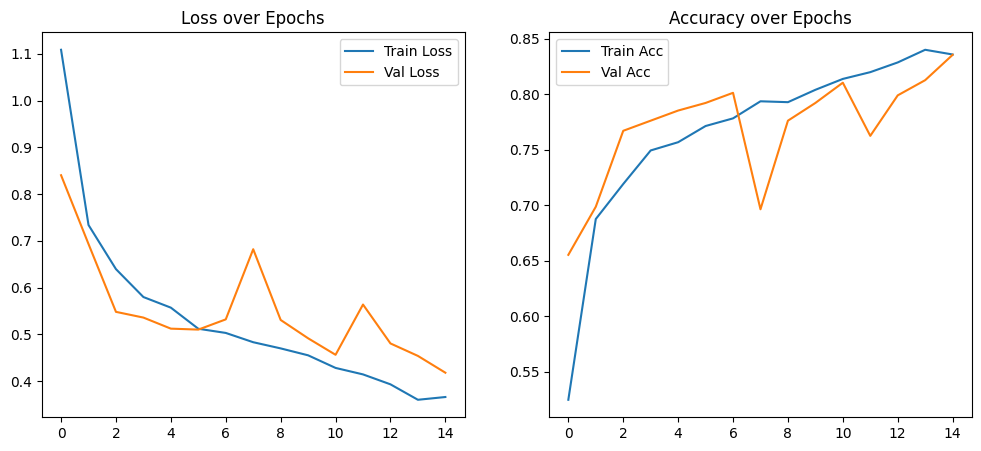

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()


### 7. Evaluate on Test Split

Classification Report:
              precision    recall  f1-score   support

       heavy       0.92      0.90      0.91       167
    incident       0.88      0.89      0.88        56
       light       0.94      0.79      0.86       129
    moderate       0.61      0.83      0.71        65

    accuracy                           0.86       417
   macro avg       0.84      0.85      0.84       417
weighted avg       0.87      0.86      0.86       417



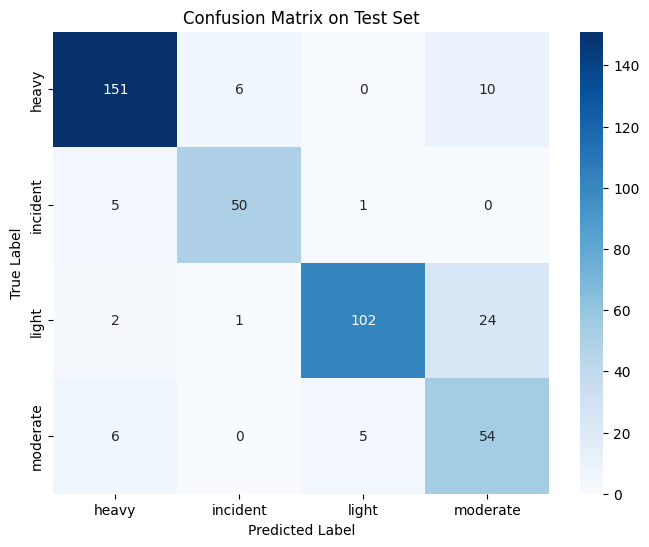

In [16]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()


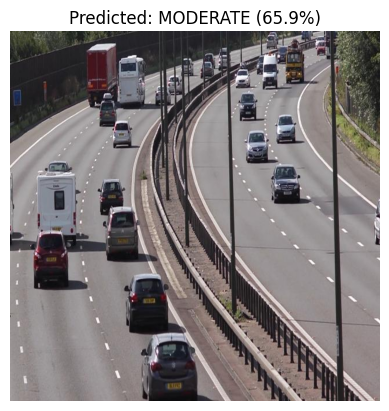

Class Probabilities:
  Heavy: 24.11%
  Incident: 1.43%
  Light: 8.54%
  Moderate: 65.91%


In [19]:
import torch.nn.functional as F
from PIL import Image

def predict_single_image(image_path):
    # Ensure model is in evaluation mode
    model.eval()
    
    # Load and preprocess the image
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return
        
    # Apply the same validation transforms and add a batch dimension
    input_tensor = data_transforms['val'](image).unsqueeze(0).to(device)
    
    # Run inference
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]
        
        confidence, predicted_idx = torch.max(probabilities, 0)
        predicted_class = class_names[predicted_idx]
        
    # Display the picture along with the prediction
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class.upper()} ({confidence.item()*100:.1f}%)")
    plt.show()
    
    # Print out detailed probabilities
    print("Class Probabilities:")
    for i, cls_name in enumerate(class_names):
        print(f"  {cls_name.capitalize()}: {probabilities[i].item() * 100:.2f}%")

# -- Usage --
# Replace with the path to any image you want to test
test_image_path = "test.jpg" # Example path
predict_single_image(test_image_path)
